# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. The intuition of adding a penalty to mean squared error that grows in the size of the model parameters is to incorporate constraints in order to reduce overfitting. So it's treated like an additional cost if the constraint is violated, and adds it to the function. Increasing lambda strengthens this effect and reduces variance. 
2. Regularization provides a way to explore the bias-variance trade-off by adjusting the strength of the penalty term lambda. By tuning lambda, we can move between underfitting and overfitting, allowing us to find a balance that minimizes overall prediction error.
3. The main difference between LASSO and Ridge regression is in the type of penalty applied to the model parameters. Ridge regression uses an L2 penalty (squared values of the coefficients), and LASSO uses an L1 penalty (absolute values of the coefficients).

    Ridge regression shrinks coefficients toward zero but does not make them exactly zero, so it keeps all features in the model. LASSO can shrink some coefficients exactly to zero, which is basically feature selection. LASSO tends to produce simpler models, while Ridge produces more stable models when predictors are highly correlated.

4. We typically standardize variables before applying regularized regression by subtracting the mean and dividing by the standard deviation, so each feature has mean 0 and variance 1. Without scaling, variables on larger scales would be penalized differently, leading to biased coefficient estimates.

5. We use techniques like k-fold cross-validation to evaluate model performance across different values of α. The value that gives the lowest average validation error is selected.
6. No, when conducting cross-validation we do not include the penalty term in the evaluation. We compute the mean squared error with only the prediction error on the validation set because the goal of cross-validation is to estimate how well the model generalizes to new data. The penalty term is only used during training to control model complexity, but it is not part of the actual prediction error.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV
from sklearn.metrics import mean_squared_error

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [2]:
# 1.
df = pd.read_csv('./data/cars_hw.csv')

# Create Age column
df['Age'] = 2026 - df['Make_Year']
X_raw = df[['Age', 'Mileage_Run']]
y = df['Price']

# Polynomial expansion
expander = PolynomialFeatures(degree=3, include_bias=False)
Z = expander.fit_transform(X_raw)
names = expander.get_feature_names_out()

# Z-score normalization
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(Z)

In [3]:
# 2.
# Fit linear regression model
model = LinearRegression()
model.fit(Z_scaled, y)

# Find interaction sign
interaction_index = list(names).index('Age Mileage_Run')
interaction_coef = model.coef_[interaction_index]
print(f'Interaction sign: {interaction_coef}') # Milage and Age have a negative interaction on price

Interaction sign: -1671212.3563918886


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.340e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.332e+12, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.774e+12, toleran

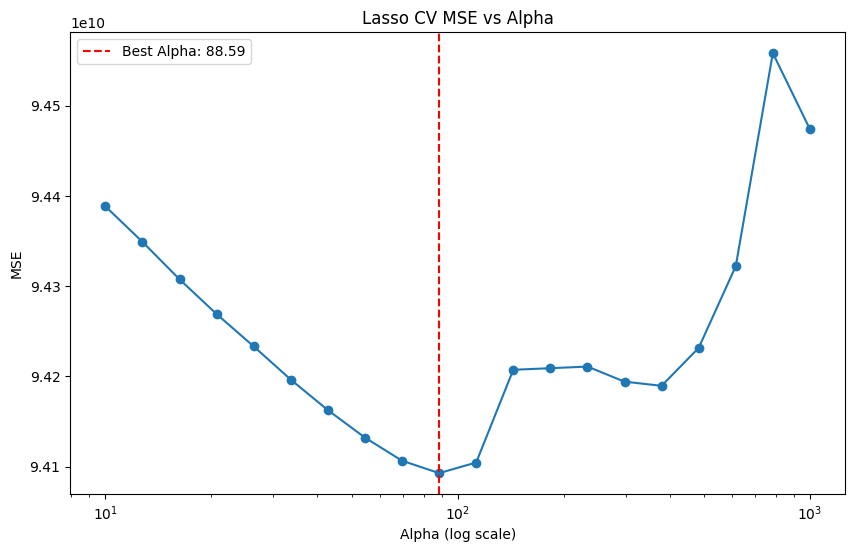

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.590e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.688e+12, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.094e+13, toleran

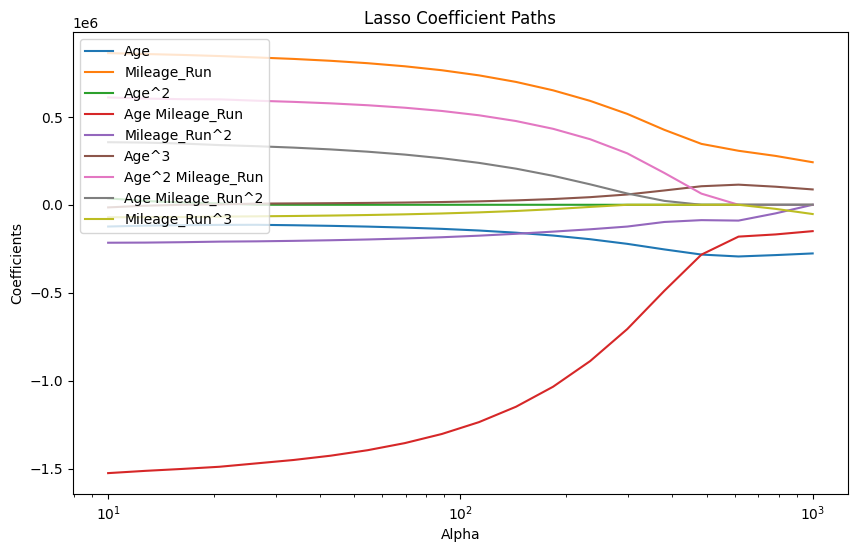

In [4]:
# 3. Lasso CV 20`fold cross validation`
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas,cv=20,random_state=42)
lasso_cv.fit(Z_scaled, y)

# 4. plot cv mse
plt.figure(figsize=(10, 6))
avg_mse = lasso_cv.mse_path_.mean(axis=1)
plt.plot(lasso_cv.alphas_, avg_mse, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('MSE')
plt.title('Lasso CV MSE vs Alpha')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Best Alpha: {lasso_cv.alpha_:.2f}')
plt.legend()
plt.show()

# 5. plot coefficient paths
alphas_path, coefs_path, _ = lasso_cv.path(Z_scaled, y, alphas=alphas)
plt.figure(figsize=(10, 6))
for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i, :], label=names[i])

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficient Paths')
plt.legend(loc='upper left')
plt.show()

In [5]:
# 6. Selected features
print(names[lasso_cv.coef_ != 0])

lasso_cv.coef_
print("Proportion set to zero:", np.mean(lasso_cv.coef_ == 0))

# 7. compare coefficients
print(f'Lasso CV: {lasso_cv.coef_}')
print(f'Linear Regression: {model.coef_}')
print("Yes, there are magnitude and sign changes between the linear regression and lasso regression coefficients, which indicates that the regularization has influenced the model's feature selection and coefficient estimation.")

['Age' 'Mileage_Run' 'Age^2' 'Age Mileage_Run' 'Mileage_Run^2' 'Age^3'
 'Age^2 Mileage_Run' 'Age Mileage_Run^2' 'Mileage_Run^3']
Proportion set to zero: 0.0
Lasso CV: [  -4116.31623837  461723.78737017 -519277.03609522 -614984.05692702
  -56931.62503759  394639.28212512  126167.88009545  202836.32488956
 -109478.15831847]
Linear Regression: [ -248172.18553828   911774.84022262   350550.71987748 -1671212.35639189
  -207292.62832857  -210037.88763613   716781.5818002    338819.45991531
   -65144.89659918]
Yes, there are magnitude and sign changes between the linear regression and lasso regression coefficients, which indicates that the regularization has influenced the model's feature selection and coefficient estimation.


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [ ]:
# 1.
df = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
df.head()

# expansion
X_raw = df[['age', 'ejection_fraction', 'serum_creatinine']]


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?